
# Laboratorio 2 – Complejidad y Búsqueda de Hiperparámetros  
**Curso:** ISIS2611  
**Caso:** AlpesHearth  

**Estudiantes:**  
- Nikol Katherin Rodriguez Ortiz - 202317538
- Nombre 2  



## 1. Introducción

En este laboratorio se evalúan diferentes enfoques de modelado para estimar el riesgo cardiovascular:

- Regresión polinomial  
- Regresión regularizada (Ridge y Lasso)  
- Regresión polinomial regularizada  

Se analiza el impacto de la complejidad en la generalización y se estiman intervalos de confianza mediante bootstrapping.


## 2. Carga de Librerías

In [126]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


## 3. Carga del Dataset

In [127]:
# Cargar el dataset limpio
dataset = pd.read_csv("dataset_limpio.csv")
df =dataset.copy()

df.head()



,Patient ID,Date of Service,Sex,Age,Weight (kg),Abdominal Circumference (cm),Total Cholesterol (mg/dL),HDL (mg/dL),Fasting Blood Sugar (mg/dL),Smoking Status,Diabetes Status,Physical Activity Level,Family History of CVD,Height (cm),Systolic BP,Diastolic BP,CVD Risk Score
0,QgsB2968,01 Aug 20,M,40,56.0,84.20,155.0,53.0,104.0,N,N,Moderate,Y,185.000,144.0,85.0,13.600
1,GcaU3177,01 Aug 24,M,63,55.0,103.18,252.0,42.0,147.0,N,N,Low,Y,174.204,101.0,77.0,15.069
2,ywdP2642,01 Jan 22,F,58,98.0,74.60,281.0,68.0,126.0,N,N,Moderate,N,186.000,133.0,83.0,17.910
3,FFib5797,01 Jul 20,M,42,108.0,106.70,186.0,79.0,73.0,N,Y,High,Y,165.000,103.0,82.0,18.770
4,ZzGw2657,01 Jun 23,M,45,62.0,84.10,141.0,45.0,117.0,Y,Y,High,N,180.000,117.0,60.0,14.510


In [128]:


# Copia del dataset
df = df.copy()

# ===============================
# 1. ELIMINAR COLUMNAS INÚTILES
# ===============================
cols_to_drop = [
    'Patient ID',        # ID no aporta info
    'Date of Service'    # Fecha cruda (si no usas features temporales)
]

df = df.drop(columns=cols_to_drop)

# ===============================
# 2. BINARIAS (SI/NO)
# ===============================
binary_cols = [
    'Smoking Status',
    'Diabetes Status',
    'Family History of CVD'
]

for col in binary_cols:
    df[col] = df[col].map({'Y':1, 'N':0})

# ===============================
# 3. SEXO (M/F)
# ===============================
df['Sex'] = df['Sex'].map({'M':1, 'F':0})

# ===============================
# 4. ACTIVIDAD FÍSICA (ORDINAL)
# ===============================
activity_map = {
    'Low':0,
    'Moderate':1,
    'High':2
}
df['Physical Activity Level'] = df['Physical Activity Level'].map(activity_map)

# ===============================
# 5. VERIFICAR RESULTADO
# ===============================
print(df.head())
print("\nShape:", df.shape)
print("\nTipos:")
print(df.dtypes)

   Sex  Age  Weight (kg)  Abdominal Circumference (cm)  \
0    1   40         56.0                         84.20   
1    1   63         55.0                        103.18   
2    0   58         98.0                         74.60   
3    1   42        108.0                        106.70   
4    1   45         62.0                         84.10   

   Total Cholesterol (mg/dL)  HDL (mg/dL)  Fasting Blood Sugar (mg/dL)  \
0                      155.0         53.0                        104.0   
1                      252.0         42.0                        147.0   
2                      281.0         68.0                        126.0   
3                      186.0         79.0                         73.0   
4                      141.0         45.0                        117.0   

   Smoking Status  Diabetes Status  Physical Activity Level  \
0               0                0                        1   
1               0                0                        0   
2               0

In [129]:
X = df.drop(columns=["CVD Risk Score"])
y = df["CVD Risk Score"]

# Hold-out
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

cv = KFold(n_splits=10, shuffle=True, random_state=42)

## 4. Modelo de Regresión Polinomial

In [ ]:
pipe_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", LinearRegression())
])

param_poly = {
    "poly__degree": [1,2,3,4,5],
    "scaler": [StandardScaler(), MinMaxScaler()]
}

grid_poly = GridSearchCV(pipe_poly, param_poly, cv=cv, scoring="neg_mean_squared_error")
grid_poly.fit(X_train, y_train)

best_poly = grid_poly.best_estimator_

y_pred = best_poly.predict(X_test)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred))
mae_poly = mean_absolute_error(y_test, y_pred)
r2_poly = r2_score(y_test, y_pred)

print(   'RMSE: ' + str(rmse_poly) + " MAE: " + str(mae_poly) + " R2: " + str(r2_poly))

POLINOMIAL:RMSE: 1.2047387016088476 MAE: 0.8507954280105824 R2: 0.778780180678947


In [131]:
degrees = range(1,6)
means = []
stds = []

from sklearn.model_selection import cross_val_score

for d in degrees:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=d)),
        ("model", LinearRegression())
    ])
    
    scores = cross_val_score(pipe, X_train, y_train, cv=10, scoring="neg_mean_squared_error")
    scores = -scores
    means.append(scores.mean())
    stds.append(scores.std())

In [132]:
print("Mejores hiperparámetros:", grid_poly.best_params_)
print("Mejor MSE (negativo) en validación cruzada:", -grid_poly.best_score_)

Mejores hiperparámetros: {'poly__degree': 1, 'scaler': StandardScaler()}
Mejor MSE (negativo) en validación cruzada: 1.4340983143367216


In [133]:
best_index = grid_poly.best_index_
best_std = grid_poly.cv_results_['std_test_score'][best_index]
print(f"Desviación estándar del MSE en CV: {best_std:.4f}")

Desviación estándar del MSE en CV: 0.3088


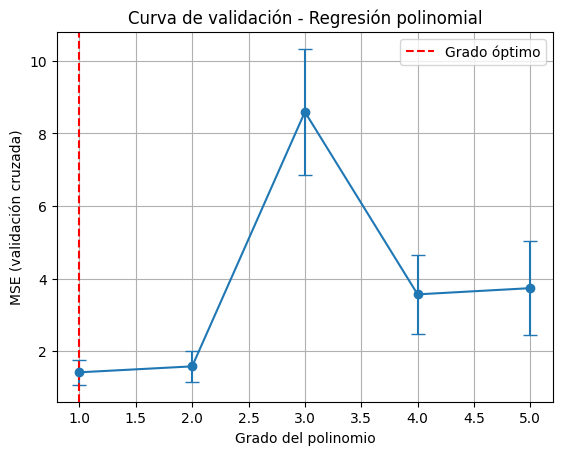

In [134]:
plt.errorbar(degrees, means, yerr=stds, marker="o", capsize=5)
plt.axvline(x=grid_poly.best_params_['poly__degree'], color='r', linestyle='--', label='Grado óptimo')
plt.title("Curva de validación - Regresión polinomial")
plt.xlabel("Grado del polinomio")
plt.ylabel("MSE (validación cruzada)")
plt.legend()
plt.grid(True)
plt.show()

## 5. Modelos Regularizados (Ridge y Lasso)

In [145]:
pipe_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_ridge = {
    "model__alpha": [0.01, 0.1, 1, 10, 100],
    "scaler": [StandardScaler(), MinMaxScaler()]
}

grid_ridge = GridSearchCV(pipe_ridge, param_ridge, cv=cv, scoring="neg_mean_squared_error")
grid_ridge.fit(X_train, y_train)

best_ridge = grid_ridge.best_estimator_

y_pred = best_ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred))
mae_ridge = mean_absolute_error(y_test, y_pred)
r2_ridge = r2_score(y_test, y_pred)

print("RMSE: "+ str(rmse_ridge) + " MAE: " + str( mae_ridge)  + " R2: " + str(r2_ridge))

RMSE: 1.20507242581068 MAE: 0.8526067600815398 R2: 0.7786576036705947


In [ ]:
pipe_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=5000))
])

param_lasso = {
    "model__alpha": [0.001, 0.01, 0.1, 1],
    "scaler": [StandardScaler(), MinMaxScaler()]
}

grid_lasso = GridSearchCV(pipe_lasso, param_lasso, cv=cv, scoring="neg_mean_squared_error")
grid_lasso.fit(X_train, y_train)

best_lasso = grid_lasso.best_estimator_

y_pred = best_lasso.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred))
mae_lasso = mean_absolute_error(y_test, y_pred)
r2_lasso = r2_score(y_test, y_pred)

print("RMSE: "+ str(rmse_lasso) + " MAE: " + str( mae_lasso)  + " R2: " + str(r2_lasso))

LASSO: 1.2133237290333803 0.8850294106919796 0.7756161003152837


In [ ]:
# Línea base: Regresión Lineal sin regularización
pipe_lineal = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

# Entrenar y evaluar en test
pipe_lineal.fit(X_train, y_train)
y_pred_lineal = pipe_lineal.predict(X_test)

rmse_lineal = np.sqrt(mean_squared_error(y_test, y_pred_lineal))
mae_lineal = mean_absolute_error(y_test, y_pred_lineal)
r2_lineal = r2_score(y_test, y_pred_lineal)

print("RMSE: "+ str(rmse_lineal) + " MAE: " + str( mae_lineal)  + " R2: " + str(r2_lineal))

LINEAL (sin regularizar): 1.2047387016088476 0.8507954280105823 0.778780180678947


In [138]:
# Análisis de coeficientes
# Obtener nombres de las características (asumiendo que X_train es un DataFrame)
feature_names = X_train.columns

# Coeficientes del modelo lineal (sin regularizar)
coef_lineal = pipe_lineal.named_steps['model'].coef_
print("\n--- Coeficientes del modelo lineal (sin regularizar) ---")
for name, coef in zip(feature_names, coef_lineal):
    print(f"{name}: {coef:.4f}")

# Coeficientes del mejor modelo Ridge
coef_ridge = best_ridge.named_steps['model'].coef_
print("\n--- Coeficientes del mejor modelo Ridge ---")
print("Mejor alpha:", best_ridge.named_steps['model'].alpha)
for name, coef in zip(feature_names, coef_ridge):
    print(f"{name}: {coef:.4f}")

# Coeficientes del mejor modelo Lasso
coef_lasso = best_lasso.named_steps['model'].coef_
print("\n--- Coeficientes del mejor modelo Lasso ---")
print("Mejor alpha:", best_lasso.named_steps['model'].alpha)
ceros = sum(coef_lasso == 0)
print(f"Variables con coeficiente cero: {ceros} de {len(feature_names)}")
for name, coef in zip(feature_names, coef_lasso):
    estado = " (cero)" if coef == 0 else ""
    print(f"{name}: {coef:.4f}{estado}")

# Reflexión: ¿qué variables selecciona Lasso?


--- Coeficientes del modelo lineal (sin regularizar) ---
Sex: 0.0082
Age: 0.0318
Weight (kg): 0.9074
Abdominal Circumference (cm): 0.0469
Total Cholesterol (mg/dL): 1.1348
HDL (mg/dL): -0.0337
Fasting Blood Sugar (mg/dL): 0.0242
Smoking Status: 0.0218
Diabetes Status: 1.0342
Physical Activity Level: 0.0156
Family History of CVD: 0.0372
Height (cm): -0.2282
Systolic BP: 1.0403
Diastolic BP: 0.0538

--- Coeficientes del mejor modelo Ridge ---
Mejor alpha: 0.1
Sex: 0.0166
Age: 0.1407
Weight (kg): 6.0229
Abdominal Circumference (cm): 0.3069
Total Cholesterol (mg/dL): 6.1001
HDL (mg/dL): -0.1983
Fasting Blood Sugar (mg/dL): 0.1294
Smoking Status: 0.0435
Diabetes Status: 2.0692
Physical Activity Level: 0.0376
Family History of CVD: 0.0742
Height (cm): -1.3846
Systolic BP: 5.1405
Diastolic BP: 0.2863

--- Coeficientes del mejor modelo Lasso ---
Mejor alpha: 0.01
Variables con coeficiente cero: 7 de 14
Sex: 0.0000 (cero)
Age: 0.0000 (cero)
Weight (kg): 5.6395
Abdominal Circumference (cm): 0.0

In [139]:
# Para Ridge
ridge_cv_mse = -grid_ridge.best_score_
ridge_cv_std = grid_ridge.cv_results_['std_test_score'][grid_ridge.best_index_]
print(f"Ridge CV RMSE: {np.sqrt(ridge_cv_mse):.4f} ± {np.sqrt(ridge_cv_std):.4f}")

Ridge CV RMSE: 1.1975 ± 0.5542


## 6. Modelo Polinomial Regularizado

In [ ]:
pipe_poly_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", Ridge())
])

param_poly_ridge = {
    "poly__degree": [1,2,3,4,5],
    "model__alpha": [0.01, 0.1, 1, 10],
    "scaler": [StandardScaler(), MinMaxScaler()]
}

grid_poly_ridge = GridSearchCV(
    pipe_poly_ridge,
    param_poly_ridge,
    cv=cv,
    scoring="neg_mean_squared_error"
)

grid_poly_ridge.fit(X_train, y_train)
best_poly_ridge = grid_poly_ridge.best_estimator_

y_pred = best_poly_ridge.predict(X_test)

rmse_poly_ridge = np.sqrt(mean_squared_error(y_test, y_pred))
mae_poly_ridge = mean_absolute_error(y_test, y_pred)
r2_poly_ridge = r2_score(y_test, y_pred)

print("RMSE: "+ str(rmse_poly_ridge) + " MAE: " + str( mae_poly_ridge)  + " R2: " + str(r2_poly_ridge))

POLY+RIDGE: 1.20507242581068 0.8526067600815401 0.7786576036705947


In [141]:
# Mejores hiperparámetros
print("Mejores hiperparámetros (Poly+Ridge):", grid_poly_ridge.best_params_)

# Mejor puntaje (MSE negativo) en validación cruzada
best_cv_mse = -grid_poly_ridge.best_score_
best_cv_std = grid_poly_ridge.cv_results_['std_test_score'][grid_poly_ridge.best_index_]
print(f"MSE en validación cruzada: {best_cv_mse:.4f} ± {best_cv_std:.4f}")
print(f"RMSE en validación cruzada: {np.sqrt(best_cv_mse):.4f}")

Mejores hiperparámetros (Poly+Ridge): {'model__alpha': 0.1, 'poly__degree': 1, 'scaler': MinMaxScaler()}
MSE en validación cruzada: 1.4340 ± 0.3072
RMSE en validación cruzada: 1.1975


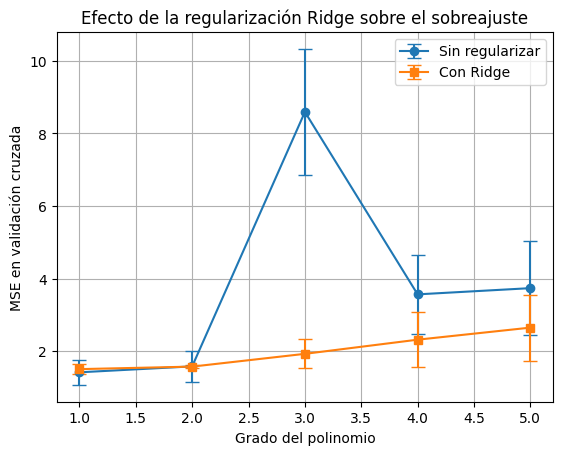

In [142]:
# Obtener resultados del GridSearch para Poly+Ridge
results_cv = pd.DataFrame(grid_poly_ridge.cv_results_)

# Filtrar por el mejor escalador (para simplificar, o agrupar por grado)
# Suponiendo que el mejor escalador es StandardScaler (por ejemplo)
best_scaler = grid_poly_ridge.best_params_['scaler']
mask = results_cv['param_scaler'] == best_scaler
filtered = results_cv[mask]

# Calcular media y std del MSE para cada grado (promediando sobre alphas)
grouped = filtered.groupby('param_poly__degree')['mean_test_score'].agg(['mean', 'std'])
grouped['mean_mse'] = -grouped['mean']
grouped['std_mse'] = grouped['std']

# Grados evaluados
degrees_ridge = grouped.index.astype(int)
degrees_unreg = list(range(1, len(means) + 1))

# Graficar junto con la curva del polinomio sin regularizar (obtenida antes)
plt.errorbar(degrees_unreg, means, yerr=stds, marker='o', label='Sin regularizar', capsize=5)
plt.errorbar(degrees_ridge, grouped['mean_mse'], yerr=grouped['std_mse'], marker='s', label='Con Ridge', capsize=5)
plt.xlabel('Grado del polinomio')
plt.ylabel('MSE en validación cruzada')
plt.title('Efecto de la regularización Ridge sobre el sobreajuste')
plt.legend()
plt.grid(True)
plt.show()

In [143]:
results = pd.DataFrame({
    "Modelo": ["Polinomial", "Ridge", "Lasso", "Poly+Ridge"],
    "RMSE": [rmse_poly, rmse_ridge, rmse_lasso, rmse_poly_ridge],
    "MAE": [mae_poly, mae_ridge, mae_lasso, mae_poly_ridge],
    "R2": [r2_poly, r2_ridge, r2_lasso, r2_poly_ridge]
})

results.sort_values("RMSE")

,Modelo,RMSE,MAE,R2
0,Polinomial,1.204739,0.850795,0.778780
1,Ridge,1.205072,0.852607,0.778658
3,Poly+Ridge,1.205072,0.852607,0.778658
2,Lasso,1.213324,0.885029,0.775616


## 7. Intervalos de Confianza (Bootstrapping)


## 8. Uso de Herramientas de IA Generativa

**Herramienta utilizada:** ChatGPT  

**Tipo de uso:**  
- Apoyo conceptual  
- Generación inicial de estructura  
- Explicación de regularización y bootstrapping  

**Prompts utilizados:**  
- "Explícame la diferencia entre Ridge y Lasso"  
- "Cómo implementar bootstrapping en sklearn"  

**Análisis crítico y aportes propios:**  
(Completar por los estudiantes)
